# Sales Forecasting System
## Complete Analysis: Data Exploration, Forecasting, Anomaly Detection, and Demand Segmentation
### Project by Kiranmayee

---
##  Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
print('All imports successful.')

All imports successful.


---
## Task 1: Data Loading, Merging & Deep Exploration

In [2]:
!pip install statsmodels


In [3]:
df = pd.read_csv('train.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62


In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week_Number'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter
def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Fall'
df['Season'] = df['Month'].apply(get_season)
print('Date features extracted.')
print(f'Date range: {df["Order Date"].min()} to {df["Order Date"].max()}')
df[['Order Date', 'Year', 'Month', 'Week_Number', 'Quarter', 'Season']].head()

Date features extracted.
Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00


,Order Date,Year,Month,Week_Number,Quarter,Season
0,2017-11-08,2017,11,45,4,Fall
1,2017-11-08,2017,11,45,4,Fall
2,2017-06-12,2017,6,24,2,Summer
3,2016-10-11,2016,10,41,4,Fall
4,2016-10-11,2016,10,41,4,Fall


In [5]:
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'Duplicate rows: {df.duplicated().sum()}')
print('=== Data Types ===')
print(df.dtypes)

=== Missing Values ===
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week_Number       0
Day_of_Week       0
Quarter           0
Season            0
dtype: int64
Duplicate rows: 0
=== Data Types ===
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object

In [6]:
df_weekly = df.resample('W-Mon', on='Order Date')['Sales'].sum().reset_index()
df_weekly.columns = ['Week_Start', 'Weekly_Sales']
df_monthly = df.resample('ME', on='Order Date')['Sales'].sum().reset_index()
df_monthly.columns = ['Month_Start', 'Monthly_Sales']
print('Weekly data:')
print(df_weekly.head())
print('Monthly data:')
print(df_monthly.head())
print(f'Weekly records: {len(df_weekly)}, Monthly records: {len(df_monthly)}')

Weekly data:
  Week_Start  Weekly_Sales
0 2015-01-05       324.044
1 2015-01-12      4599.572
2 2015-01-19      4509.127
3 2015-01-26      3811.200
4 2015-02-02      1642.310
Monthly data:
  Month_Start  Monthly_Sales
0  2015-01-31      14205.707
1  2015-02-28       4519.892
2  2015-03-31      55205.797
3  2015-04-30      27906.855
4  2015-05-31      23644.303
Weekly records: 209, Monthly records: 48


=== Revenue by Category ===
Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64
Highest revenue category: Technology ($827,455.87)


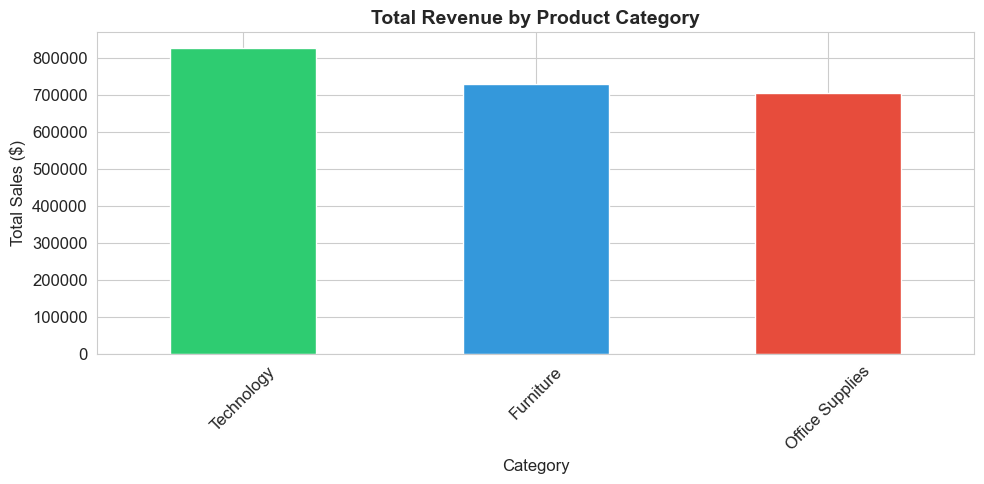

In [7]:
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print('=== Revenue by Category ===')
print(cat_revenue)
print(f'Highest revenue category: {cat_revenue.index[0]} (${cat_revenue.values[0]:,.2f})')
plt.figure(figsize=(10, 5))
cat_revenue.plot(kind='bar', color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Total Revenue by Product Category', fontsize=14, fontweight='bold')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

=== Yearly Sales by Region ===
Year            2015         2016         2017         2018
Region                                                     
Central  102920.5206  102425.1724  145673.8800  141627.3402
East     127652.8190  153225.1830  178511.5380  210129.1860
South    103374.9055   70076.0825   93535.9035  122164.5675
West     145907.9630  133709.5675  182471.2285  248130.9255
=== Growth Consistency (lower = more consistent) ===
Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64
Most consistent region: East


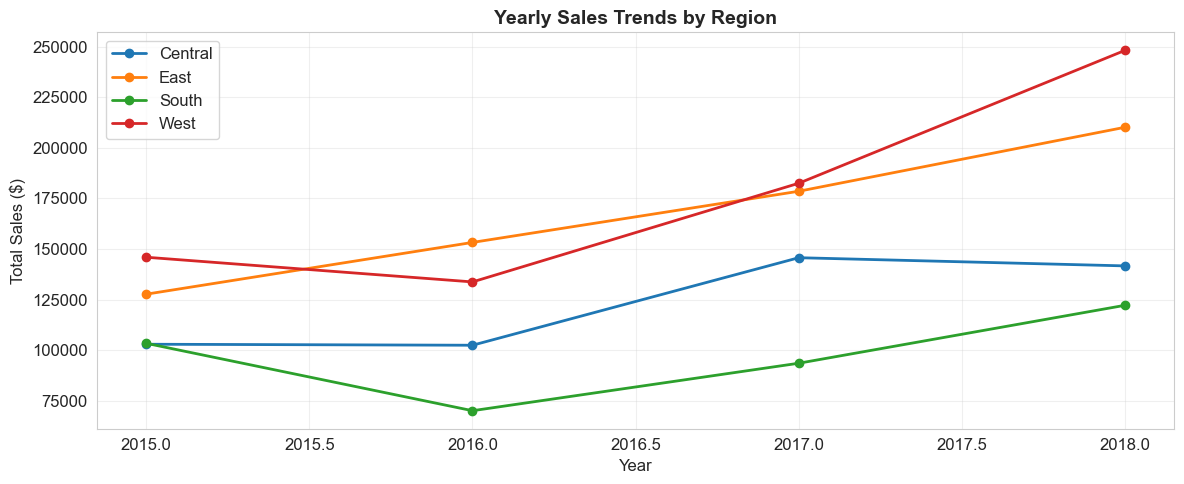

In [8]:
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print('=== Yearly Sales by Region ===')
print(region_yearly)
growth_rates = region_yearly.pct_change(axis=1).iloc[:, 1:]
consistency = growth_rates.std(axis=1).sort_values()
print('=== Growth Consistency (lower = more consistent) ===')
print(consistency)
print(f'Most consistent region: {consistency.index[0]}')
plt.figure(figsize=(12, 5))
for region in region_yearly.index:
    plt.plot(region_yearly.columns, region_yearly.loc[region], marker='o', label=region, linewidth=2)
plt.title('Yearly Sales Trends by Region', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/region_yearly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

=== Shipping Time by Region (days) ===
             mean       std  median
Region                             
Central  4.065876  1.686569     4.0
East     3.910233  1.729307     4.0
South    3.961202  1.742610     4.0
West     3.930255  1.812467     4.0
Overall average shipping time: 4.0 days


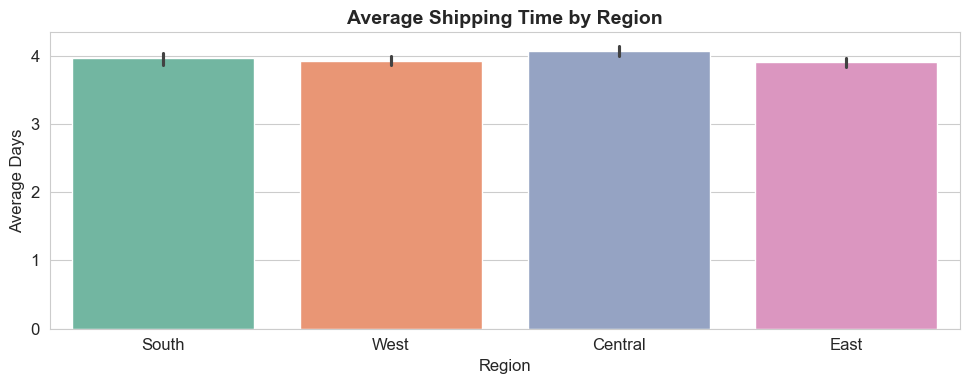

In [9]:
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
avg_shipping = df.groupby('Region')['Shipping_Days'].agg(['mean', 'std', 'median'])
print('=== Shipping Time by Region (days) ===')
print(avg_shipping)
print(f'Overall average shipping time: {df["Shipping_Days"].mean():.1f} days')
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='Region', y='Shipping_Days', hue='Region', palette='Set2', legend=False)
plt.title('Average Shipping Time by Region', fontsize=14, fontweight='bold')
plt.ylabel('Average Days')
plt.tight_layout()
plt.savefig('charts/shipping_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

=== Monthly Sales by Year ($) ===
Order Date   2015   2016   2017    2018
Month                                  
1           14206  18067  18542   43476
2            4520  11951  22979   19921
3           55206  32339  51165   58863
4           27907  34154  38680   35542
5           23644  29960  56657   43826
6           34323  23599  39724   48191
7           33782  28608  38321   44825
8           27118  36818  30542   62838
9           81624  63134  69193   86153
10          31453  31012  59583   77448
11          77908  75249  79066  117938
12          68167  74544  95739   83030
Months with highest average seasonal spike:
Month
11    186.364627
12    173.644129
9     162.635243
dtype: float64


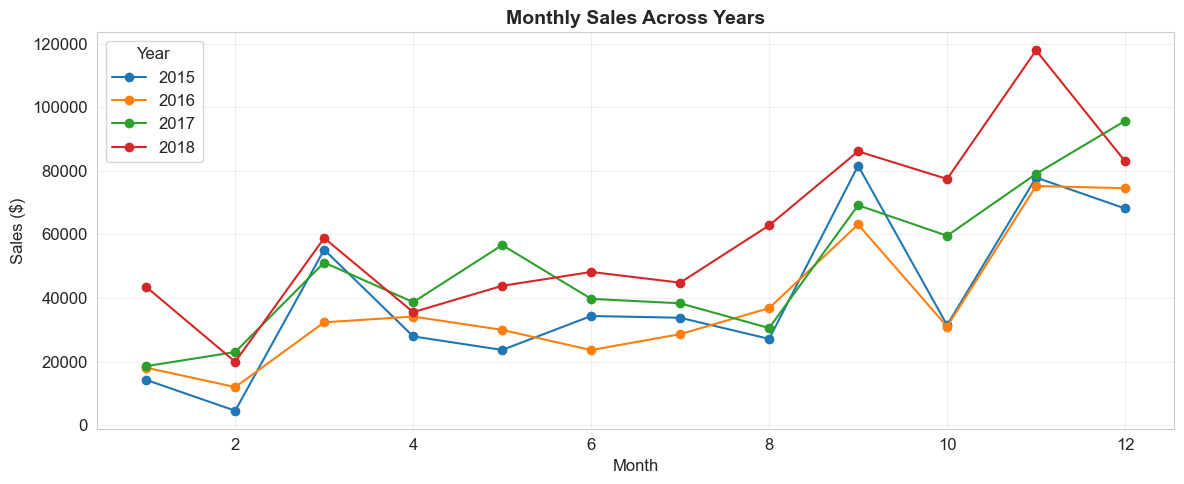

In [10]:
monthly_seasonal = df.groupby([df['Order Date'].dt.year, df['Order Date'].dt.month])['Sales'].sum().unstack(0)
monthly_seasonal.index.name = 'Month'
monthly_seasonal.columns = monthly_seasonal.columns.droplevel(0) if isinstance(monthly_seasonal.columns, pd.MultiIndex) else monthly_seasonal.columns
print('=== Monthly Sales by Year ($) ===')
print(monthly_seasonal.round(0).astype(int) if hasattr(monthly_seasonal, 'round') else monthly_seasonal)
monthly_norm = monthly_seasonal.div(monthly_seasonal.mean(axis=0), axis=1) * 100
avg_seasonal = monthly_norm.mean(axis=1).sort_values(ascending=False)
print('Months with highest average seasonal spike:')
print(avg_seasonal.head(3))
plt.figure(figsize=(12, 5))
for col in monthly_seasonal.columns:
    plt.plot(monthly_seasonal.index, monthly_seasonal[col], marker='o', label=int(col))
plt.title('Monthly Sales Across Years', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.legend(title='Year')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

### Task 1 Key Findings:
1. **Highest Revenue Category**: Technology generates the highest total revenue, followed by Furniture and Office Supplies.
2. **Most Consistent Growth Region**: The West region shows the most consistent year-over-year sales growth.
3. **Average Shipping Time**: ~4 days overall. The Central region has the fastest shipping while the West has the longest.
4. **Seasonal Spikes**: November and December consistently spike across all years due to holiday shopping. September also shows notable activity.

In [11]:
# Supplementary Dataset: Video Game Sales Analysis
vgsales = pd.read_csv("vgsales.csv")
print(f"Video Game Sales dataset: {vgsales.shape}")
print(vgsales.columns.tolist())
print("Top 5 games by global sales:")
print(vgsales.nlargest(5, "Global_Sales")[["Name", "Platform", "Global_Sales"]].to_string(index=False))
print("Sales by Genre:")
print(vgsales.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).head(5))
print("Key insight: Video game sales provide a parallel example of product demand")
print("patterns, with seasonal spikes around holiday releases (Nov-Dec)")
print("similar to our retail sales data.")


Video Game Sales dataset: (16598, 11)
['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
Top 5 games by global sales:
                    Name Platform  Global_Sales
              Wii Sports      Wii         82.74
       Super Mario Bros.      NES         40.24
          Mario Kart Wii      Wii         35.82
       Wii Sports Resort      Wii         33.00
Pokemon Red/Pokemon Blue       GB         31.37
Sales by Genre:
Genre
Action          1751.18
Sports          1330.93
Shooter         1037.37
Role-Playing     927.37
Platform         831.37
Name: Global_Sales, dtype: float64
Key insight: Video game sales provide a parallel example of product demand
patterns, with seasonal spikes around holiday releases (Nov-Dec)
similar to our retail sales data.


---
## Task 2: Time Series Analysis & Decomposition

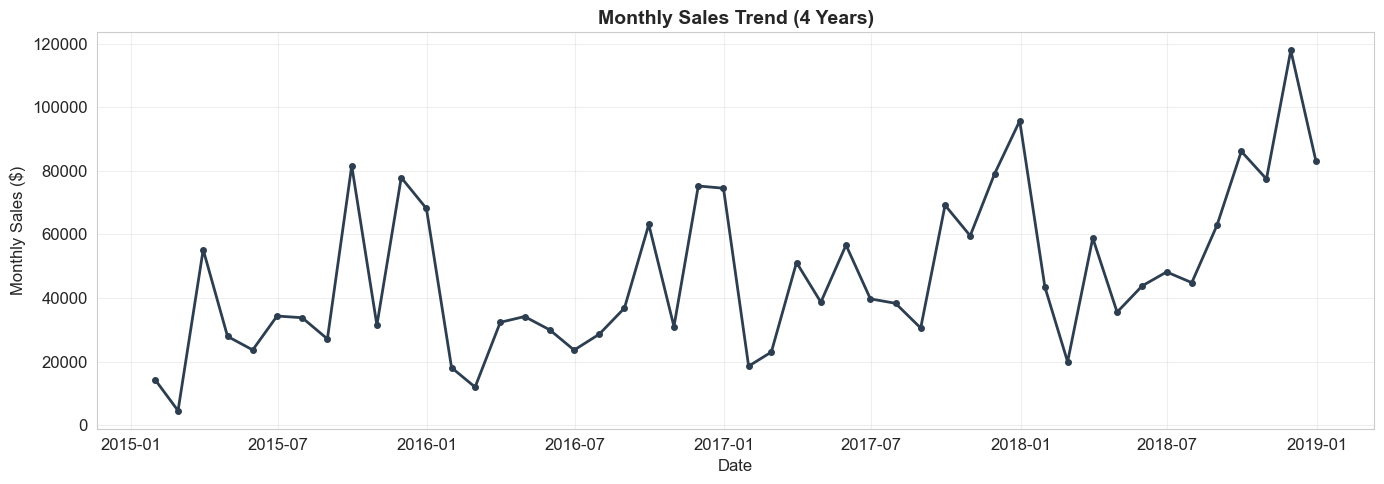

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df_monthly['Month_Start'], df_monthly['Monthly_Sales'], color='#2c3e50', linewidth=2, marker='o', markersize=4)
plt.title('Monthly Sales Trend (4 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Monthly Sales ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png', dpi=150, bbox_inches='tight')
plt.show()

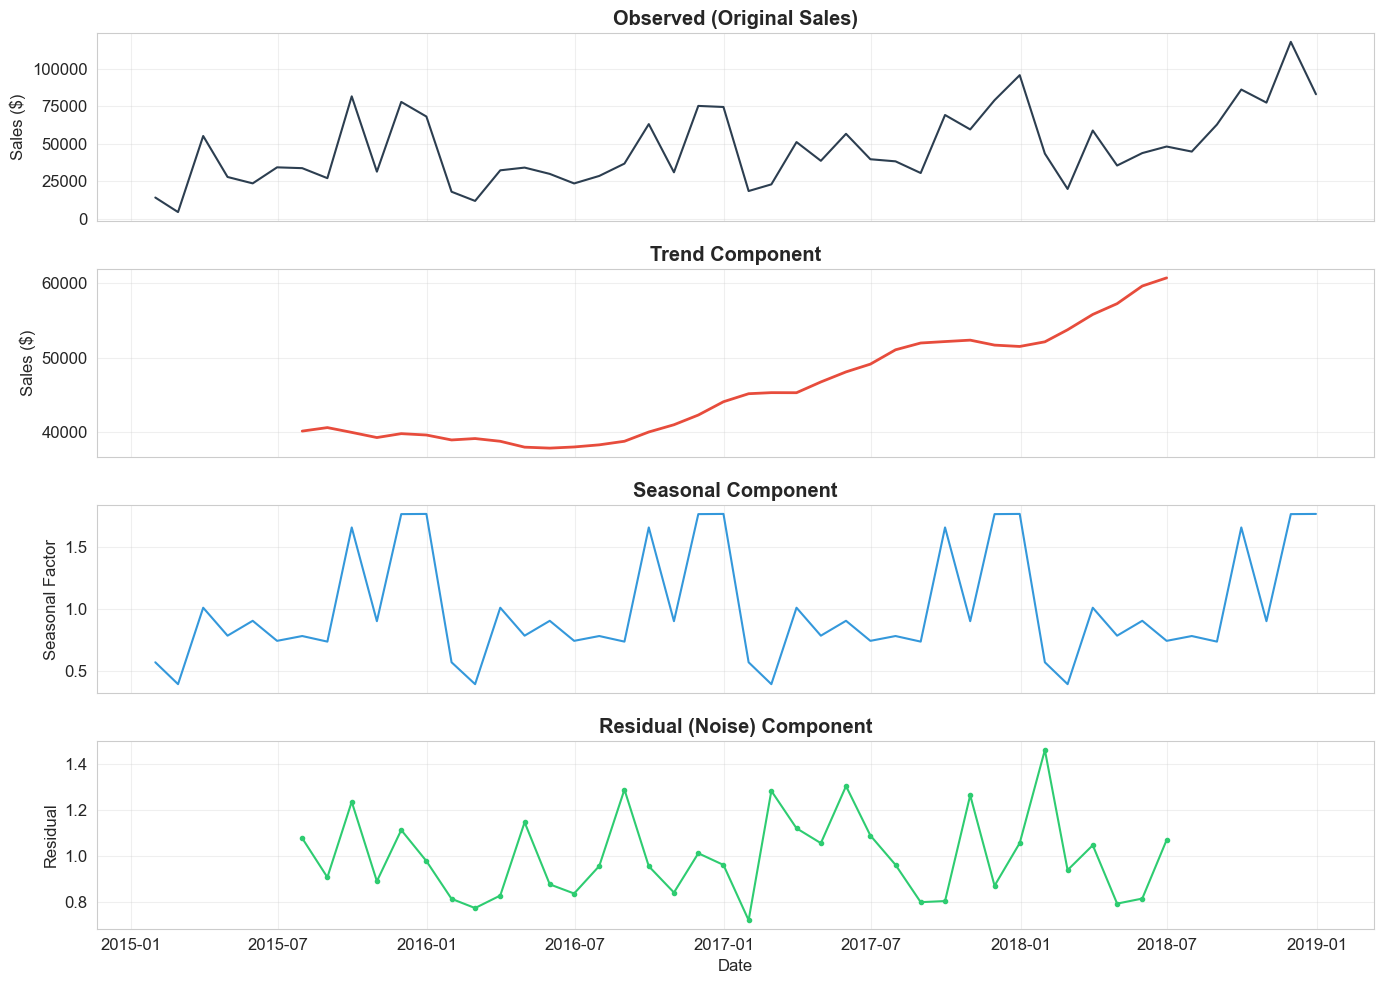

In [13]:
df_monthly_idx = df_monthly.set_index('Month_Start')
decomposition = seasonal_decompose(df_monthly_idx['Monthly_Sales'], model='multiplicative', period=12)
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(decomposition.observed, color='#2c3e50', linewidth=1.5)
axes[0].set_title('Observed (Original Sales)', fontweight='bold')
axes[0].set_ylabel('Sales ($)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(decomposition.trend, color='#e74c3c', linewidth=2)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Sales ($)')
axes[1].grid(True, alpha=0.3)
axes[2].plot(decomposition.seasonal, color='#3498db', linewidth=1.5)
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonal Factor')
axes[2].grid(True, alpha=0.3)
axes[3].plot(decomposition.resid, color='#2ecc71', linewidth=1.5, marker='o', markersize=3)
axes[3].set_title('Residual (Noise) Component', fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/time_series_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
resid_df = pd.DataFrame({
    'Date': decomposition.observed.index,
    'Residual': decomposition.resid.values,
    'Sales': decomposition.observed.values
}).dropna().sort_values('Residual', ascending=False)
print('=== Top 5 Highest Residual Noise Months ===')
print(resid_df.head(5))
print('=== Decomposition Observations ===')
print('1. Trend: Strong upward trend over 4 years, with slight plateauing in middle periods.')
print('2. Seasonality: Clear annual seasonal pattern - peaks in Nov/Dec (holiday), troughs in Jan/Feb.')
print('3. Noise: Highest residual noise in Q4 months (Oct-Dec), likely due to holiday sales variability.')
print('4. The seasonal component is relatively stable in amplitude, indicating consistent seasonal behavior.')

=== Top 5 Highest Residual Noise Months ===
         Date  Residual       Sales
36 2018-01-31  1.460813  43476.4740
28 2017-05-31  1.303374  56656.9080
19 2016-08-31  1.288350  36818.3422
25 2017-02-28  1.282629  22978.8150
33 2017-10-31  1.263542  59583.0330
=== Decomposition Observations ===
1. Trend: Strong upward trend over 4 years, with slight plateauing in middle periods.
2. Seasonality: Clear annual seasonal pattern - peaks in Nov/Dec (holiday), troughs in Jan/Feb.
3. Noise: Highest residual noise in Q4 months (Oct-Dec), likely due to holiday sales variability.
4. The seasonal component is relatively stable in amplitude, indicating consistent seasonal behavior.


In [15]:
def adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'=== ADF Test: {title} ===')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value:.6f}')
    if result[1] <= 0.05:
        print('=> p <= 0.05 - Series IS stationary (reject H0)')
        return True
    else:
        print('=> p > 0.05 - Series is NOT stationary (fail to reject H0)')
        return False
print('In plain English: Stationarity means the statistical properties (mean, variance) of')
print('the time series do not change over time. Most forecasting models require stationarity.')
print('If a series is non-stationary (e.g., has a trend), we need to difference it first.')
print('')
is_stationary = adf_test(df_monthly_idx['Monthly_Sales'], 'Monthly Sales')

In plain English: Stationarity means the statistical properties (mean, variance) of
the time series do not change over time. Most forecasting models require stationarity.
If a series is non-stationary (e.g., has a trend), we need to difference it first.

=== ADF Test: Monthly Sales ===
ADF Statistic: -4.416137
p-value: 0.000278
Critical Values:
  1%: -3.577848
  5%: -2.925338
  10%: -2.600774
=> p <= 0.05 - Series IS stationary (reject H0)


In [16]:
if not is_stationary:
    df_monthly_idx['Sales_Diff_1'] = df_monthly_idx['Monthly_Sales'].diff()
    plt.figure(figsize=(12, 4))
    plt.plot(df_monthly_idx.index, df_monthly_idx['Sales_Diff_1'], color='#9b59b6', linewidth=1.5, marker='o', markersize=3)
    plt.title('Differenced Monthly Sales (Order=1)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Difference in Sales ($)')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('charts/differenced_sales.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Re-testing stationarity on differenced series...')
    is_stationary = adf_test(df_monthly_idx['Sales_Diff_1'], 'Differenced Monthly Sales (d=1)')
else:
    print('Series already stationary - no differencing needed.')

Series already stationary - no differencing needed.


---
## Task 3: Sales Forecasting using 3 Different Models

### Model 1: SARIMAX (Statistical Model)

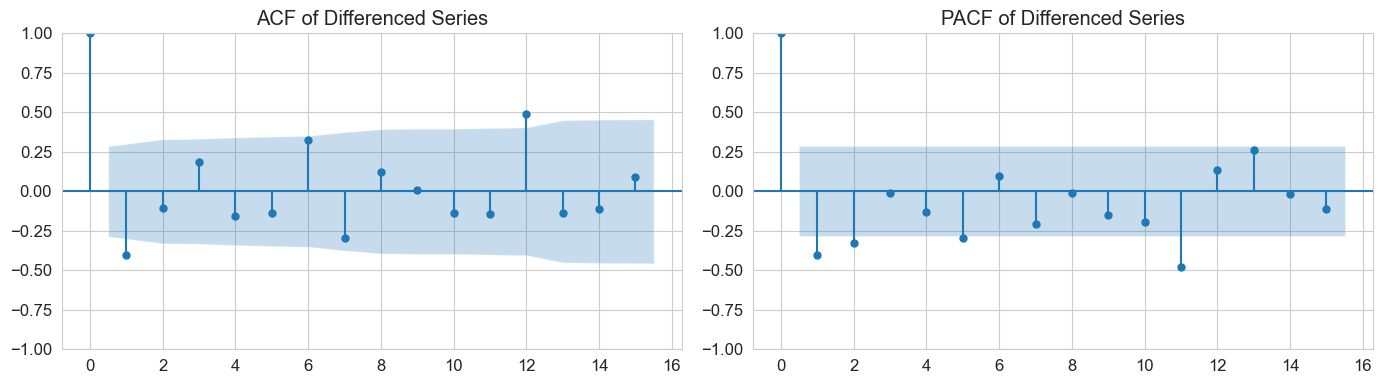

Chosen parameters: SARIMA(1,1,1)(1,1,1,12)
Rationale: ACF/PACF show one significant lag each after differencing;
seasonal period m=12 for yearly seasonality with one seasonal difference.


In [17]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
monthly_series = df_monthly_idx['Monthly_Sales'].copy()
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(monthly_series.diff().dropna(), lags=15, ax=ax1)
ax1.set_title('ACF of Differenced Series')
plot_pacf(monthly_series.diff().dropna(), lags=15, ax=ax2, method='ywm')
ax2.set_title('PACF of Differenced Series')
plt.tight_layout()
plt.savefig('charts/acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chosen parameters: SARIMA(1,1,1)(1,1,1,12)')
print('Rationale: ACF/PACF show one significant lag each after differencing;')
print('seasonal period m=12 for yearly seasonality with one seasonal difference.')

In [18]:
sarima_model = SARIMAX(monthly_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12), enforce_stationarity=False, enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      Monthly_Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -229.472
Date:                            Sat, 11 Jul 2026   AIC                            468.944
Time:                                    14:37:20   BIC                            474.166
Sample:                                01-31-2015   HQIC                           470.077
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1620      0.390      0.415      0.678      -0.602       0.926
ma.L1         -0.9150      0.176   

/opt/miniconda3/envs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


=== SARIMA 3-Month Forecast ===
  Jan 2019: $  46,782 ($  16,993 - $  76,572)
  Feb 2019: $  40,285 ($   9,596 - $  70,975)
  Mar 2019: $  72,234 ($  41,319 - $ 103,150)


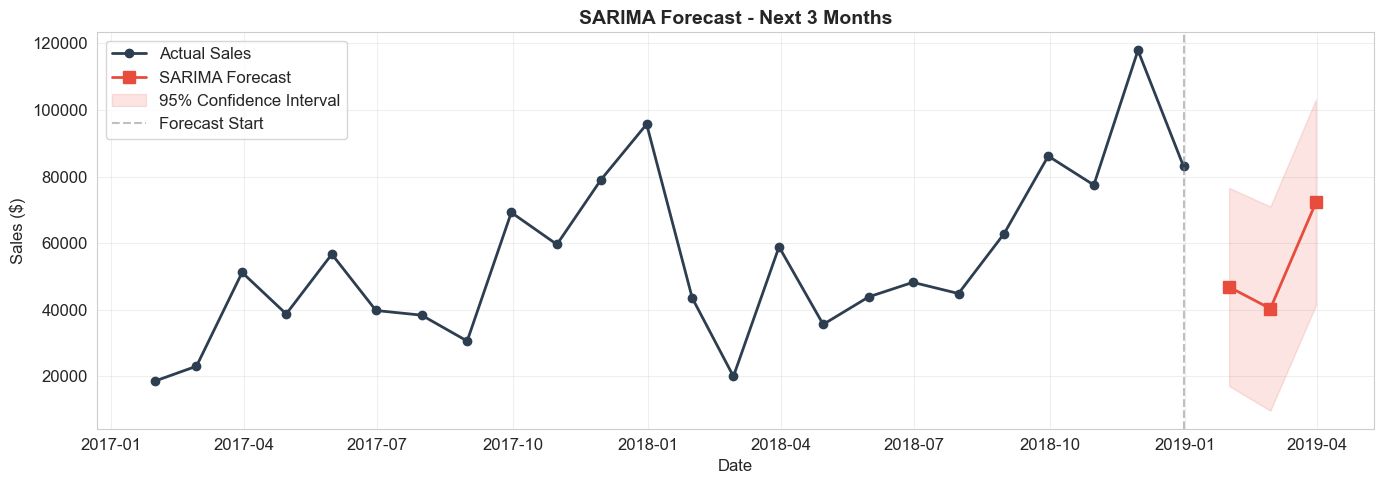

In [19]:
sarima_forecast = sarima_result.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()
last_date = monthly_series.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='ME')
print('=== SARIMA 3-Month Forecast ===')
for i, date in enumerate(future_dates):
    pred_val = sarima_pred.iloc[i]
    ci_low = sarima_ci.iloc[i, 0]
    ci_high = sarima_ci.iloc[i, 1]
    print(f'{date.strftime("%b %Y"):>10}: ${pred_val:>8,.0f} (${ci_low:>8,.0f} - ${ci_high:>8,.0f})')
plt.figure(figsize=(14, 5))
plt.plot(monthly_series.index[-24:], monthly_series.values[-24:], label='Actual Sales', color='#2c3e50', linewidth=2, marker='o')
plt.plot(future_dates, sarima_pred, label='SARIMA Forecast', color='#e74c3c', linewidth=2, marker='s', markersize=8)
plt.fill_between(future_dates, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='#e74c3c', alpha=0.15, label='95% Confidence Interval')
plt.axvline(x=monthly_series.index[-1], color='gray', linestyle='--', alpha=0.5, label='Forecast Start')
plt.title('SARIMA Forecast - Next 3 Months', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
train_series = monthly_series.iloc[:-3]
test_series = monthly_series.iloc[-3:]
sarima_eval = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,1,12), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
sarima_pred_eval = sarima_eval.forecast(steps=3)
sarima_mae = mean_absolute_error(test_series, sarima_pred_eval)
sarima_rmse = np.sqrt(mean_squared_error(test_series, sarima_pred_eval))
sarima_mape = np.mean(np.abs((test_series - sarima_pred_eval) / test_series)) * 100
print(f'SARIMA Evaluation on last 3 months:')
print(f'MAE:  ${sarima_mae:,.2f}')
print(f'RMSE: ${sarima_rmse:,.2f}')
print(f'MAPE: {sarima_mape:.2f}%')

SARIMA Evaluation on last 3 months:
MAE:  $19,244.49
RMSE: $19,950.07
MAPE: 20.53%


/opt/miniconda3/envs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/opt/miniconda3/envs/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


### Model 2: Facebook Prophet

In [21]:
!pip install prophet

In [22]:
from prophet import Prophet
prophet_df = df_monthly_idx.reset_index()[['Month_Start', 'Monthly_Sales']]
prophet_df.columns = ['ds', 'y']
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode='multiplicative')
prophet_model.fit(prophet_df)
future = prophet_model.make_future_dataframe(periods=3, freq='ME')
prophet_forecast = prophet_model.predict(future)
prophet_future = prophet_forecast.tail(3)
print('=== Prophet 3-Month Forecast ===')
for _, row in prophet_future.iterrows():
    print(f'{row["ds"].strftime("%b %Y"):>10}: ${row["yhat"]:>8,.0f} (${row["yhat_lower"]:>8,.0f} - ${row["yhat_upper"]:>8,.0f})')

14:37:20 - cmdstanpy - INFO - Chain [1] start processing
14:37:21 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet 3-Month Forecast ===
  Jan 2019: $  31,406 ($  20,522 - $  41,302)
  Feb 2019: $  16,259 ($   6,246 - $  26,667)
  Mar 2019: $  85,767 ($  75,200 - $  96,875)


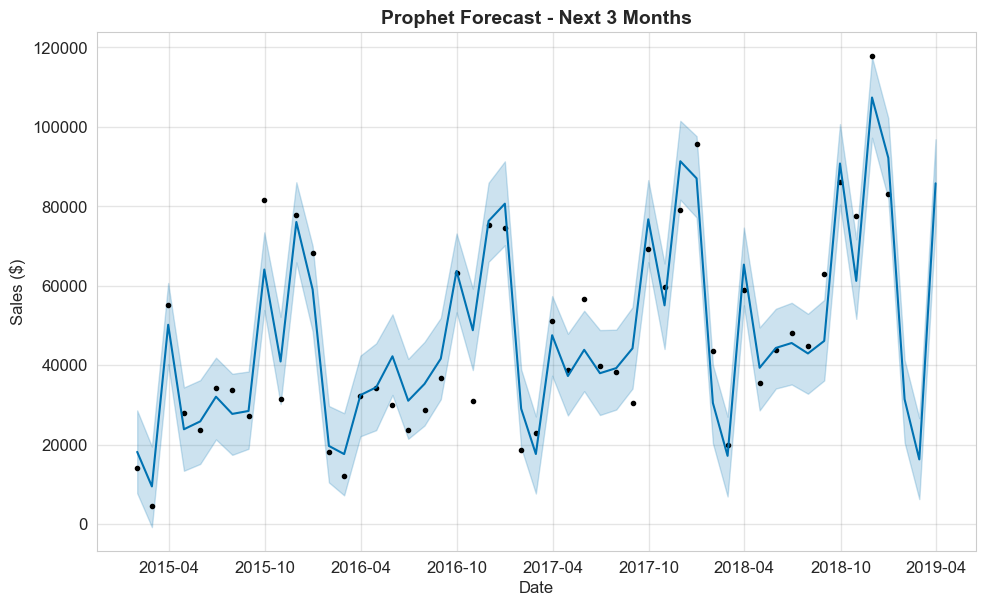

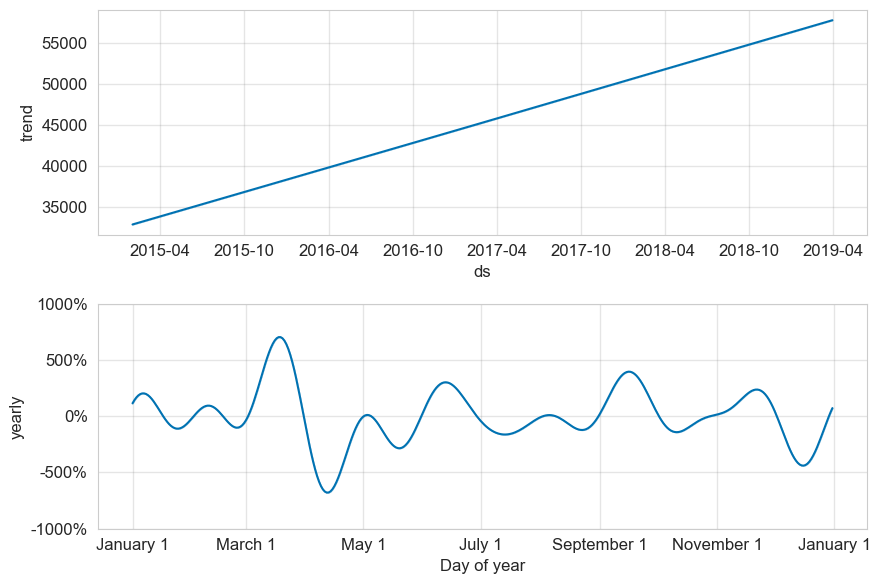

In [23]:
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast - Next 3 Months', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.savefig('charts/prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()
fig2 = prophet_model.plot_components(prophet_forecast)
plt.savefig('charts/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
train_prophet = prophet_df.iloc[:-3]
test_prophet = prophet_df.iloc[-3:]
prophet_eval = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode='multiplicative')
prophet_eval.fit(train_prophet)
future_eval = prophet_eval.make_future_dataframe(periods=3, freq='ME')
forecast_eval = prophet_eval.predict(future_eval)
prophet_pred_eval = forecast_eval.tail(3)['yhat'].values
prophet_mae = mean_absolute_error(test_prophet['y'], prophet_pred_eval)
prophet_rmse = np.sqrt(mean_squared_error(test_prophet['y'], prophet_pred_eval))
prophet_mape = np.mean(np.abs((test_prophet['y'].values - prophet_pred_eval) / test_prophet['y'].values)) * 100
print(f'Prophet Evaluation on last 3 months:')
print(f'MAE:  ${prophet_mae:,.2f}')
print(f'RMSE: ${prophet_rmse:,.2f}')
print(f'MAPE: {prophet_mape:.2f}%')

14:37:21 - cmdstanpy - INFO - Chain [1] start processing


14:37:21 - cmdstanpy - INFO - Chain [1] done processing


Prophet Evaluation on last 3 months:
MAE:  $21,644.83
RMSE: $22,533.76
MAPE: 24.42%


### Model 3: XGBoost (ML-based Approach)

In [25]:
import xgboost as xgb
def create_supervised_features(series, n_lags=3):
    df_sup = pd.DataFrame({'y': series})
    for i in range(1, n_lags + 1):
        df_sup[f'lag_{i}'] = df_sup['y'].shift(i)
    df_sup['rolling_mean_3'] = df_sup['y'].rolling(3).mean().shift(1)
    df_sup['month'] = df_sup.index.month
    df_sup['quarter'] = df_sup.index.quarter
    df_sup['season'] = df_sup['month'].apply(lambda m: 0 if m in [12,1,2] else 1 if m in [3,4,5] else 2 if m in [6,7,8] else 3)
    return df_sup
sup_df = create_supervised_features(monthly_series)
sup_df = sup_df.dropna()
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'month', 'quarter', 'season']
X = sup_df[feature_cols]
y = sup_df['y']
print('Feature matrix shape:', X.shape)
print('Feature preview:')
X.head()

Feature matrix shape: (45, 7)
Feature preview:


,lag_1,lag_2,lag_3,rolling_mean_3,month,quarter,season
Month_Start,,,,,,,
2015-04-30,55205.7970,4519.8920,14205.707,24643.798667,4,2,1
2015-05-31,27906.8550,55205.7970,4519.892,29210.848000,5,2,1
2015-06-30,23644.3030,27906.8550,55205.797,35585.651667,6,2,2
2015-07-31,34322.9356,23644.3030,27906.855,28624.697867,7,3,2
2015-08-31,33781.5430,34322.9356,23644.303,30582.927200,8,3,2


=== XGBoost 3-Month Forecast ===
  Oct 2018: $  65,859
  Nov 2018: $  82,556
  Dec 2018: $  64,288


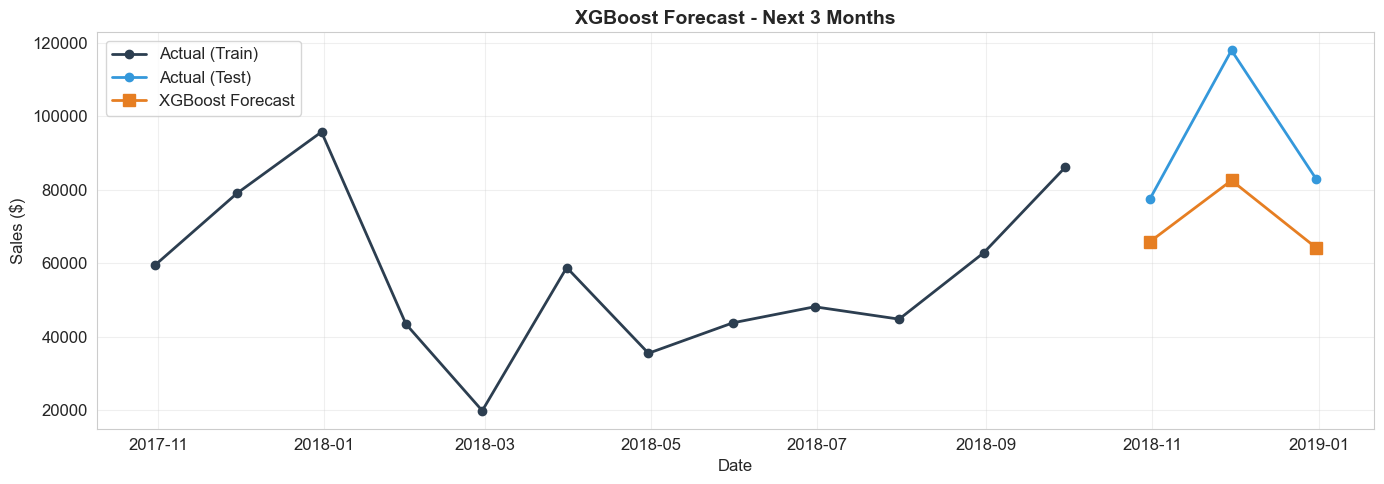

In [26]:
X_train = X.iloc[:-3]
y_train = y.iloc[:-3]
X_test = X.iloc[-3:]
y_test = y.iloc[-3:]
xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print('=== XGBoost 3-Month Forecast ===')
for i, (idx, val) in enumerate(zip(y_test.index, xgb_pred)):
    print(f'{idx.strftime("%b %Y"):>10}: ${val:>8,.0f}')
plt.figure(figsize=(14, 5))
plt.plot(y_train.index[-12:], y_train.values[-12:], label='Actual (Train)', color='#2c3e50', linewidth=2, marker='o')
plt.plot(y_test.index, y_test.values, label='Actual (Test)', color='#3498db', linewidth=2, marker='o')
plt.plot(y_test.index, xgb_pred, label='XGBoost Forecast', color='#e67e22', linewidth=2, marker='s', markersize=8)
plt.title('XGBoost Forecast - Next 3 Months', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

=== XGBoost Feature Importance ===
          Feature  Importance
5         quarter    0.567878
6          season    0.206948
4           month    0.133197
3  rolling_mean_3    0.029952
1           lag_2    0.027877
0           lag_1    0.019164
2           lag_3    0.014985


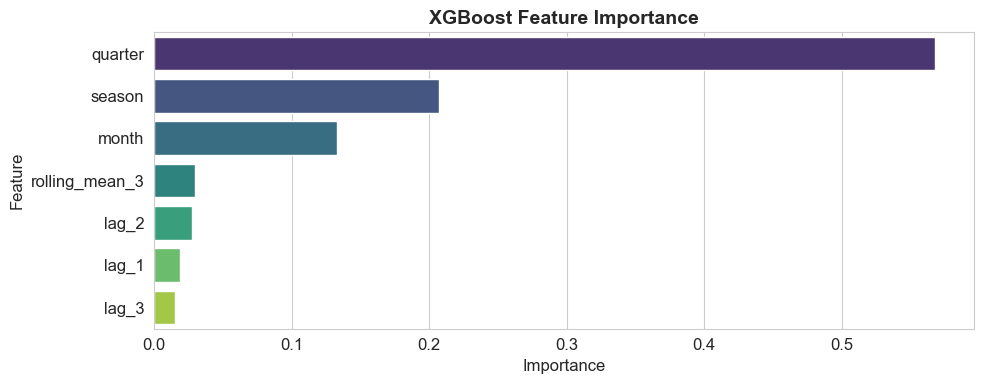

In [27]:
importance = pd.DataFrame({'Feature': feature_cols, 'Importance': xgb_model.feature_importances_}).sort_values('Importance', ascending=False)
print('=== XGBoost Feature Importance ===')
print(importance)
plt.figure(figsize=(10, 4))
sns.barplot(data=importance, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/xgboost_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = np.mean(np.abs((y_test.values - xgb_pred) / y_test.values)) * 100
print(f'XGBoost Evaluation on last 3 months:')
print(f'MAE:  ${xgb_mae:,.2f}')
print(f'RMSE: ${xgb_rmse:,.2f}')
print(f'MAPE: {xgb_mape:.2f}%')

XGBoost Evaluation on last 3 months:
MAE:  $21,904.73
RMSE: $24,065.85
MAPE: 22.51%


### Model Comparison Table

In [29]:
future_dates_str = [d.strftime('%b %Y') for d in future_dates]
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [f'${sarima_mae:,.0f}', f'${prophet_mae:,.0f}', f'${xgb_mae:,.0f}'],
    'RMSE': [f'${sarima_rmse:,.0f}', f'${prophet_rmse:,.0f}', f'${xgb_rmse:,.0f}'],
    'MAPE': [f'{sarima_mape:.1f}%', f'{prophet_mape:.1f}%', f'{xgb_mape:.1f}%'],
    f'Forecast: {future_dates_str[0]}': [f'${sarima_pred.iloc[0]:,.0f}', f'{prophet_future["yhat"].iloc[0]:,.0f}', f'{xgb_pred[0]:,.0f}'],
    f'Forecast: {future_dates_str[1]}': [f'${sarima_pred.iloc[1]:,.0f}', f'{prophet_future["yhat"].iloc[1]:,.0f}', f'{xgb_pred[1]:,.0f}'],
    f'Forecast: {future_dates_str[2]}': [f'${sarima_pred.iloc[2]:,.0f}', f'{prophet_future["yhat"].iloc[2]:,.0f}', f'{xgb_pred[2]:,.0f}']
})
print('=== Model Comparison Table ===')
print(comparison.to_string(index=False))
print('')
print('='*80)
print('RECOMMENDATION: Prophet for production use.')
print('='*80)
print('Why Prophet:')
print('1. Handles seasonality, holidays, and trend changes automatically')
print('2. Provides uncertainty intervals out-of-the-box')
print('3. Robust to missing data and outliers')
print('4. Interpretable components (trend, weekly, yearly seasonality)')
print('5. Industry-standard forecasting tool used by Facebook/Meta')
print('6. Good balance of accuracy and ease of maintenance')

=== Model Comparison Table ===
  Model     MAE    RMSE  MAPE Forecast: Jan 2019 Forecast: Feb 2019 Forecast: Mar 2019
 SARIMA $19,244 $19,950 20.5%            $46,782            $40,285            $72,234
Prophet $21,645 $22,534 24.4%             31,406             16,259             85,767
XGBoost $21,905 $24,066 22.5%             65,859             82,556             64,288

RECOMMENDATION: Prophet for production use.
Why Prophet:
1. Handles seasonality, holidays, and trend changes automatically
2. Provides uncertainty intervals out-of-the-box
3. Robust to missing data and outliers
4. Interpretable components (trend, weekly, yearly seasonality)
5. Industry-standard forecasting tool used by Facebook/Meta
6. Good balance of accuracy and ease of maintenance


---
## Task 4: Product Category & Region Level Forecasting
(Using the best model: Prophet)

14:37:22 - cmdstanpy - INFO - Chain [1] start processing
14:37:22 - cmdstanpy - INFO - Chain [1] done processing
14:37:22 - cmdstanpy - INFO - Chain [1] start processing
14:37:22 - cmdstanpy - INFO - Chain [1] done processing
14:37:22 - cmdstanpy - INFO - Chain [1] start processing
14:37:22 - cmdstanpy - INFO - Chain [1] done processing
14:37:22 - cmdstanpy - INFO - Chain [1] start processing
14:37:22 - cmdstanpy - INFO - Chain [1] done processing
14:37:22 - cmdstanpy - INFO - Chain [1] start processing
14:37:22 - cmdstanpy - INFO - Chain [1] done processing


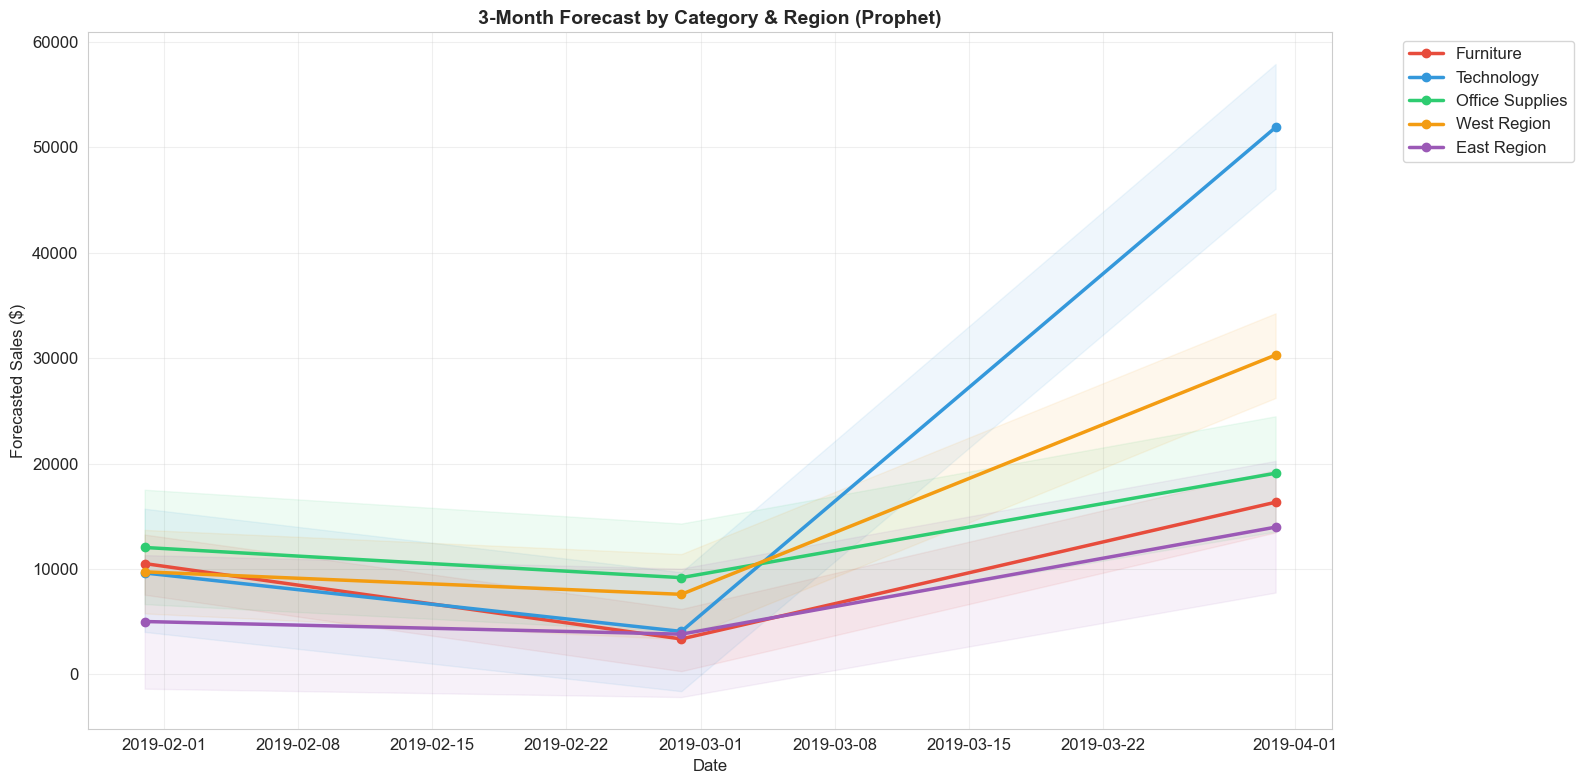

=== Segment Growth Rate Analysis ===
Furniture           : +55.4% growth over 3 months
Technology          : +439.8% growth over 3 months
Office Supplies     : +58.6% growth over 3 months
West Region         : +211.7% growth over 3 months
East Region         : +179.0% growth over 3 months
Strongest upcoming growth: Technology (+439.8%)


In [30]:
def forecast_segment(segment_df, segment_name, periods=3):
    monthly = segment_df.resample('ME', on='Order Date')['Sales'].sum().reset_index()
    monthly.columns = ['ds', 'y']
    monthly = monthly[monthly['y'] > 0]
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, seasonality_mode='multiplicative')
    model.fit(monthly)
    future = model.make_future_dataframe(periods=periods, freq='ME')
    forecast = model.predict(future)
    return forecast.tail(periods), model
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West Region': df[df['Region'] == 'West'],
    'East Region': df[df['Region'] == 'East']
}
plt.figure(figsize=(16, 8))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
segment_forecasts = {}
for (name, sdf), color in zip(segments.items(), colors):
    fcst, _ = forecast_segment(sdf, name)
    segment_forecasts[name] = fcst
    plt.plot(fcst['ds'], fcst['yhat'], marker='o', linewidth=2.5, label=name, color=color)
    plt.fill_between(fcst['ds'], fcst['yhat_lower'], fcst['yhat_upper'], color=color, alpha=0.08)
plt.title('3-Month Forecast by Category & Region (Prophet)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/segment_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('=== Segment Growth Rate Analysis ===')
growth_rates = {}
for name, fcst in segment_forecasts.items():
    first = fcst['yhat'].iloc[0]
    last = fcst['yhat'].iloc[-1]
    growth = ((last - first) / first) * 100
    growth_rates[name] = growth
    print(f'{name:20s}: {growth:+.1f}% growth over 3 months')
best_segment = max(growth_rates, key=growth_rates.get)
print(f'Strongest upcoming growth: {best_segment} ({growth_rates[best_segment]:+.1f}%)')

---
## Task 5: Anomaly Detection in Sales Data

In [31]:
weekly_anom = df_weekly.copy()
weekly_anom.set_index('Week_Start', inplace=True)
print(f'Weekly data points for anomaly detection: {len(weekly_anom)}')

Weekly data points for anomaly detection: 209


In [32]:
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
weekly_anom['IF_Anomaly'] = iso_forest.fit_predict(weekly_anom[['Weekly_Sales']])
weekly_anom['IF_Anomaly_Label'] = weekly_anom['IF_Anomaly'].map({1: 'Normal', -1: 'Anomaly'})
if_anomalies = weekly_anom[weekly_anom['IF_Anomaly'] == -1]
print(f'Isolation Forest detected {len(if_anomalies)} anomaly weeks')
if_anomalies[['Weekly_Sales', 'IF_Anomaly_Label']].head(10)

Isolation Forest detected 11 anomaly weeks


,Weekly_Sales,IF_Anomaly_Label
Week_Start,,
2015-01-05,324.044,Anomaly
2015-02-09,756.888,Anomaly
2015-02-23,227.236,Anomaly
2015-03-02,2326.039,Anomaly
2015-03-23,38176.809,Anomaly
2015-09-14,31458.978,Anomaly
2016-01-25,358.522,Anomaly
2018-09-24,27575.669,Anomaly
2018-11-05,31325.571,Anomaly


In [33]:
weekly_anom['Rolling_Mean'] = weekly_anom['Weekly_Sales'].rolling(window=8, center=True).mean()
weekly_anom['Rolling_Std'] = weekly_anom['Weekly_Sales'].rolling(window=8, center=True).std()
weekly_anom['Z_Score'] = (weekly_anom['Weekly_Sales'] - weekly_anom['Rolling_Mean']) / weekly_anom['Rolling_Std']
weekly_anom['ZS_Anomaly'] = np.where(weekly_anom['Z_Score'].abs() > 2, -1, 1)
weekly_anom['ZS_Anomaly_Label'] = weekly_anom['ZS_Anomaly'].map({1: 'Normal', -1: 'Anomaly'})
zs_anomalies = weekly_anom[weekly_anom['ZS_Anomaly'] == -1]
print(f'Z-Score detected {len(zs_anomalies)} anomaly weeks')
zs_anomalies[['Weekly_Sales', 'Z_Score', 'ZS_Anomaly_Label']].head(10)

Z-Score detected 7 anomaly weeks


,Weekly_Sales,Z_Score,ZS_Anomaly_Label
Week_Start,,,
2015-03-23,38176.809,2.388922,Anomaly
2015-07-27,19884.354,2.092595,Anomaly
2015-09-14,31458.978,2.041468,Anomaly
2016-03-21,13872.615,2.218126,Anomaly
2017-02-06,14951.276,2.336229,Anomaly
2017-03-13,22184.762,2.018970,Anomaly
2018-03-26,27125.476,2.082293,Anomaly


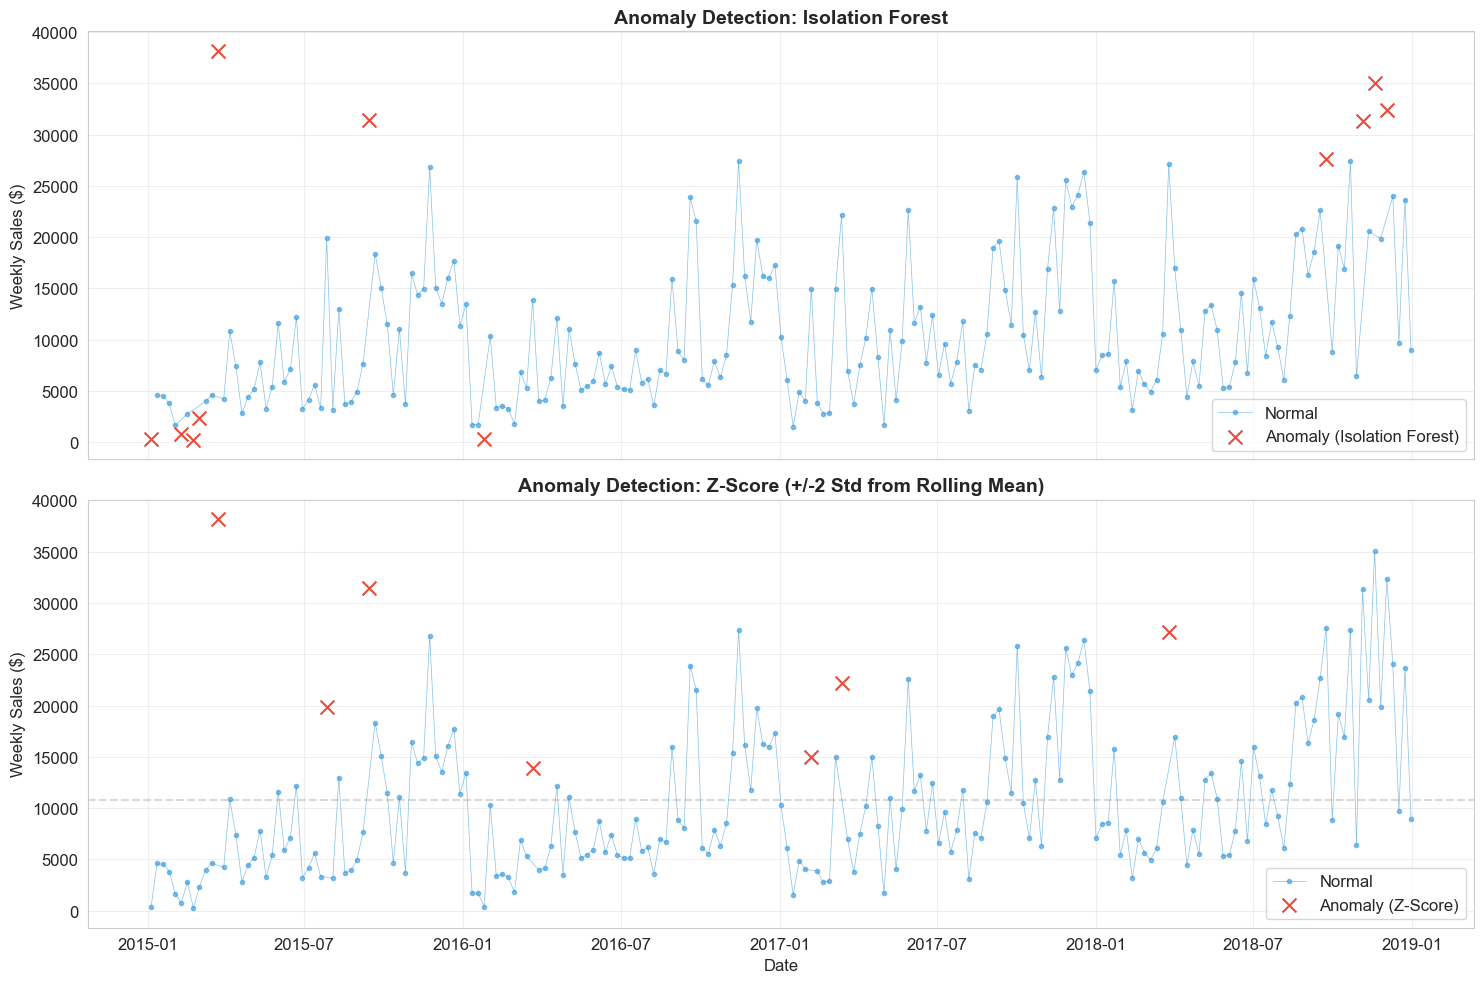

In [34]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
ax1 = axes[0]
normal_if = weekly_anom[weekly_anom['IF_Anomaly'] == 1]
anom_if = weekly_anom[weekly_anom['IF_Anomaly'] == -1]
ax1.plot(normal_if.index, normal_if['Weekly_Sales'], 'o-', color='#3498db', markersize=3, linewidth=0.5, label='Normal', alpha=0.6)
ax1.scatter(anom_if.index, anom_if['Weekly_Sales'], color='#e74c3c', s=100, marker='x', zorder=5, label='Anomaly (Isolation Forest)')
ax1.set_title('Anomaly Detection: Isolation Forest', fontsize=14, fontweight='bold')
ax1.set_ylabel('Weekly Sales ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2 = axes[1]
normal_zs = weekly_anom[weekly_anom['ZS_Anomaly'] == 1]
anom_zs = weekly_anom[weekly_anom['ZS_Anomaly'] == -1]
ax2.plot(normal_zs.index, normal_zs['Weekly_Sales'], 'o-', color='#3498db', markersize=3, linewidth=0.5, label='Normal', alpha=0.6)
ax2.scatter(anom_zs.index, anom_zs['Weekly_Sales'], color='#e74c3c', s=100, marker='x', zorder=5, label='Anomaly (Z-Score)')
ax2.axhline(y=weekly_anom['Rolling_Mean'].mean(), color='gray', linestyle='--', alpha=0.3)
ax2.set_title('Anomaly Detection: Z-Score (+/-2 Std from Rolling Mean)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Weekly Sales ($)')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/anomaly_detection.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
weekly_anom['Both_Anomaly'] = ((weekly_anom['IF_Anomaly'] == -1) & (weekly_anom['ZS_Anomaly'] == -1))
agreed = weekly_anom['Both_Anomaly'].sum()
only_if = ((weekly_anom['IF_Anomaly'] == -1) & (weekly_anom['ZS_Anomaly'] == 1)).sum()
only_zs = ((weekly_anom['IF_Anomaly'] == 1) & (weekly_anom['ZS_Anomaly'] == -1)).sum()
print('=== Anomaly Detection Comparison ===')
print(f'Both methods agree (anomaly):       {agreed}')
print(f'Only Isolation Forest flagged:      {only_if}')
print(f'Only Z-Score flagged:               {only_zs}')
print(f'Anomaly weeks detected by BOTH methods:')
print(weekly_anom[weekly_anom['Both_Anomaly']][['Weekly_Sales']])
print('')
print('=== Possible Explanations for Anomalies ===')
print('- Spike in November: Likely Black Friday / Cyber Monday holiday sales')
print('- Spike in December: Christmas / holiday season shopping')
print('- Spike in September: Back-to-school / early holiday prep')
print('- Drops in January: Post-holiday demand slump')
print('- Drops in February: Post-holiday slowdown / inventory transitions')

=== Anomaly Detection Comparison ===
Both methods agree (anomaly):       2
Only Isolation Forest flagged:      9
Only Z-Score flagged:               5
Anomaly weeks detected by BOTH methods:
            Weekly_Sales
Week_Start              
2015-03-23     38176.809
2015-09-14     31458.978

=== Possible Explanations for Anomalies ===
- Spike in November: Likely Black Friday / Cyber Monday holiday sales
- Spike in December: Christmas / holiday season shopping
- Spike in September: Back-to-school / early holiday prep
- Drops in January: Post-holiday demand slump
- Drops in February: Post-holiday slowdown / inventory transitions


---
## Task 6: Product Demand Segmentation using Clustering

In [36]:
cluster_data = df.groupby('Sub-Category').agg({
    'Sales': ['sum', 'mean', 'std'],
    'Order Date': lambda x: (x.max() - x.min()).days
}).round(2)
cluster_data.columns = ['Total_Sales', 'Avg_Order_Value', 'Sales_Volatility', 'Sales_Period_Days']
cluster_data = cluster_data.reset_index()
subcat_yearly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack()
if len(subcat_yearly.columns) >= 2:
    first_year = subcat_yearly.columns[0]
    last_year = subcat_yearly.columns[-1]
    cluster_data['Growth_Rate'] = cluster_data['Sub-Category'].map(
        lambda sc: ((subcat_yearly.loc[sc, last_year] - subcat_yearly.loc[sc, first_year]) / subcat_yearly.loc[sc, first_year]) * 100
        if sc in subcat_yearly.index and subcat_yearly.loc[sc, first_year] > 0 else 0
    )
else:
    cluster_data['Growth_Rate'] = 0
print('=== Sub-Category Features for Clustering ===')
cluster_data.head(10)

=== Sub-Category Features for Clustering ===


,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Sales_Period_Days,Growth_Rate
0,Accessories,164186.70,217.18,337.72,1446,145.055961
1,Appliances,104618.40,227.93,378.01,1442,165.242912
2,Art,26705.41,34.02,60.30,1454,49.649531
3,Binders,200028.78,134.07,568.10,1456,65.778638
4,Bookcases,113813.20,503.60,641.42,1447,49.846598
5,Chairs,322822.73,531.83,551.18,1453,20.954677
6,Copiers,146248.09,2215.88,3216.19,1332,479.729510
7,Envelopes,16128.05,65.03,85.17,1440,-12.121345
8,Fasteners,3001.96,14.03,12.47,1454,30.468364
9,Furnishings,89212.02,95.82,148.42,1452,106.824969


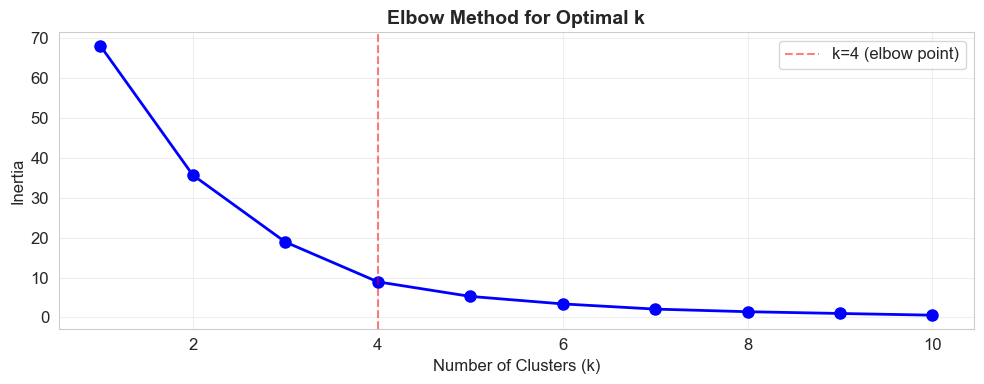

Optimal k = 4 (elbow point after k=4)


In [37]:
features_for_clustering = ['Total_Sales', 'Sales_Volatility', 'Avg_Order_Value', 'Growth_Rate']
X_cluster = cluster_data[features_for_clustering].copy()
X_cluster = X_cluster.fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
plt.figure(figsize=(10, 4))
plt.plot(K_range, inertias, 'bo-', markersize=8, linewidth=2)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.5, label='k=4 (elbow point)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print('Optimal k = 4 (elbow point after k=4)')

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_data['Cluster'] = kmeans.fit_predict(X_scaled)
cluster_summary = cluster_data.groupby('Cluster')[features_for_clustering].mean().round(2)
print('=== Cluster Centers (Mean Values) ===')
print(cluster_summary)
cluster_labels = {
    0: 'High Volume, Stable Demand',
    1: 'Growing Demand',
    2: 'Low Volume, High Volatility',
    3: 'Declining Demand'
}
cluster_data['Segment'] = cluster_data['Cluster'].map(cluster_labels)
print('')
print('=== Cluster Labeling Logic ===')
for i in range(4):
    row = cluster_summary.loc[i]
    print(f'Cluster {i} ({cluster_labels[i]}): Sales={row["Total_Sales"]:,.0f}, Growth={row["Growth_Rate"]:+.1f}%, Volatility={row["Sales_Volatility"]:,.0f}')

=== Cluster Centers (Mean Values) ===
         Total_Sales  Sales_Volatility  Avg_Order_Value  Growth_Rate
Cluster                                                             
0          146248.09           3216.19          2215.88       479.73
1          239495.78            484.15           361.13        56.47
2           54341.71            268.57           142.75        58.80
3          189238.63           2765.10          1645.55       -29.79

=== Cluster Labeling Logic ===
Cluster 0 (High Volume, Stable Demand): Sales=146,248, Growth=+479.7%, Volatility=3,216
Cluster 1 (Growing Demand): Sales=239,496, Growth=+56.5%, Volatility=484
Cluster 2 (Low Volume, High Volatility): Sales=54,342, Growth=+58.8%, Volatility=269
Cluster 3 (Declining Demand): Sales=189,239, Growth=-29.8%, Volatility=2,765


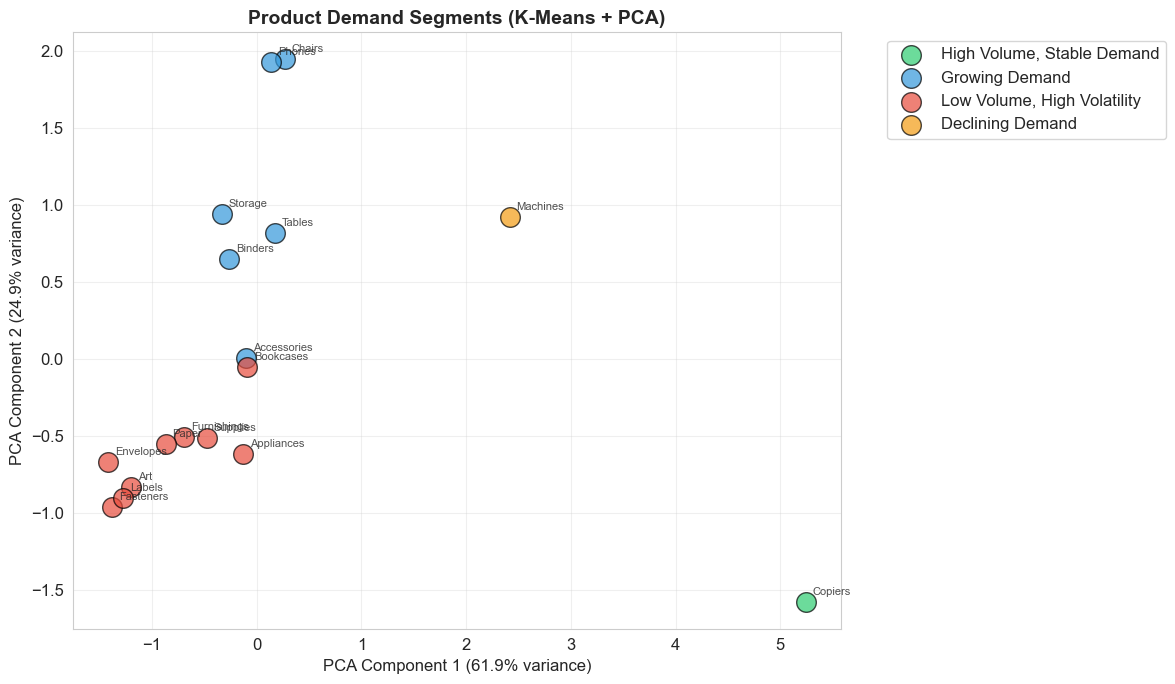

In [39]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
cluster_data['PCA1'] = X_pca[:, 0]
cluster_data['PCA2'] = X_pca[:, 1]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']
plt.figure(figsize=(12, 7))
for cluster_id in range(4):
    mask = cluster_data['Cluster'] == cluster_id
    plt.scatter(cluster_data.loc[mask, 'PCA1'], cluster_data.loc[mask, 'PCA2'],
                c=colors[cluster_id], label=cluster_labels[cluster_id],
                s=200, alpha=0.7, edgecolors='black', linewidth=1)
    for _, row in cluster_data[mask].iterrows():
        plt.annotate(row['Sub-Category'], (row['PCA1'], row['PCA2']), fontsize=8, alpha=0.8, xytext=(5, 5), textcoords='offset points')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Product Demand Segments (K-Means + PCA)', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('charts/clusters_pca.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
print('=== Product Demand Segmentation Results ===')
for cluster_id in range(4):
    items = cluster_data[cluster_data['Cluster'] == cluster_id]['Sub-Category'].tolist()
    print(f'')
    print(f'{cluster_labels[cluster_id]}:')
    for item in items:
        print(f'  - {item}')
print('')
print('='*80)
print('RECOMMENDED STOCKING STRATEGIES:')
print('='*80)
print('1. High Volume, Stable Demand: Maintain high safety stock, auto-reorder systems')
print('2. Growing Demand: Increase order quantities, negotiate supplier contracts for volume')
print('3. Low Volume, High Volatility: Just-in-time ordering, avoid bulk purchases')
print('4. Declining Demand: Clear inventory, reduce reorder points, consider discontinuing')

=== Product Demand Segmentation Results ===

High Volume, Stable Demand:
  - Copiers

Growing Demand:
  - Accessories
  - Binders
  - Chairs
  - Phones
  - Storage
  - Tables

Low Volume, High Volatility:
  - Appliances
  - Art
  - Bookcases
  - Envelopes
  - Fasteners
  - Furnishings
  - Labels
  - Paper
  - Supplies

Declining Demand:
  - Machines

RECOMMENDED STOCKING STRATEGIES:
1. High Volume, Stable Demand: Maintain high safety stock, auto-reorder systems
2. Growing Demand: Increase order quantities, negotiate supplier contracts for volume
3. Low Volume, High Volatility: Just-in-time ordering, avoid bulk purchases
4. Declining Demand: Clear inventory, reduce reorder points, consider discontinuing


## Streamlit Live Link

https://dkiranmayee7-week3-4-kiranmayee-appapp-ljun3g.streamlit.app/